# ViT-B Foul Classifier — Training & Evaluation (v2)

**Strategy:** Gradual unfreeze with proper class-weighted loss + augmentation.
- Phase 1 (frozen backbone): warm up classification heads
- Phase 2 (unfrozen): fine-tune entire model with lower backbone LR

In [1]:
from pathlib import Path
import json, sys, time, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torchvision.transforms as T

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    if (ROOT.parent / "data").exists():
        ROOT = ROOT.parent
    elif (ROOT.parent.parent / "data").exists():
        ROOT = ROOT.parent.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATASET_DIR = ROOT / "data" / "processed" / "mvfouls_dataset"
CKPT_DIR = ROOT / "checkpoints" / "vitb_v2"
LOG_DIR = ROOT / "logs" / "vitb_v2"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT:", ROOT)
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

ROOT: f:\footagent
Device: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


## 1. Configuration

In [2]:
config = {
    # Phase 1: SKIP frozen
    "phase1_epochs": 0,
    "phase1_lr": 3e-4,
    # Phase 2: full fine-tune — conservative LR to prevent overfitting
    "phase2_epochs": 30,
    "phase2_backbone_lr": 5e-5,   # 6x lower — prevent destroying pretrained features
    "phase2_head_lr": 5e-4,       # heads can learn faster
    # shared
    "batch_size": 4,
    "grad_accum_steps": 4,       # effective batch = 16
    "weight_decay": 5e-2,        # stronger L2 regularization
    "dropout": 0.5,              # stronger dropout (was 0.3)
    "patience": 10,
    "label_smoothing": 0.15,     # slightly more smoothing
}

meta_path = DATASET_DIR / "meta.json"
with open(meta_path, "r") as f:
    meta = json.load(f)

class_to_idx = meta["class_to_idx"]
idx_to_class = {int(k): v for k, v in meta["idx_to_class"].items()}
n_classes = len(class_to_idx)
print(f"{n_classes} classes: {list(class_to_idx.keys())}")

# Build proper class weight tensor (ordered by index)
# Raw weights range 0.23-25.9 (111x ratio) — too extreme for CE loss.
# Dampen with sqrt + clamp to keep ratio manageable.
raw_weights = meta["class_weights"]
idx_to_name = meta["idx_to_class"]
weight_list = []
for i in range(n_classes):
    name = idx_to_name[str(i)]
    weight_list.append(raw_weights.get(name, 1.0))
w = torch.tensor(weight_list, dtype=torch.float32)
w = torch.sqrt(w)                     # sqrt dampening
w = w / w.mean()                      # normalize to mean=1
w = torch.clamp(w, min=0.3, max=3.0)  # clamp extremes
class_weights_tensor = w.to(device)
print("Raw weights:", weight_list)
print("Dampened weights:", class_weights_tensor)

10 classes: ['', 'Challenge', 'Dive', 'Dont know', 'Elbowing', 'High leg', 'Holding', 'Pushing', 'Standing tackling', 'Tackling']
Raw weights: [25.9143, 0.7638, 10.6706, 6.3649, 1.6642, 2.7908, 0.7939, 3.3593, 0.2327, 0.6299]
Dampened weights: tensor([2.7201, 0.4670, 1.7455, 1.3481, 0.6893, 0.8927, 0.4761, 0.9794, 0.3000,
        0.4241], device='cuda:0')


## 2. Dataset with Augmentation

In [3]:
# Training augmentations (applied per-frame)
train_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    T.CenterCrop(224),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class FoulDataset(Dataset):
    """MVFouls on-the-fly loader with per-frame augmentation."""

    def __init__(self, split_name, transform=None):
        from preprocessing.mvfouls_preprocess import (
            run_full_pipeline, TARGET_FRAMES, TARGET_SIZE,
        )
        self.target_frames = TARGET_FRAMES
        self.target_size = TARGET_SIZE
        self.transform = transform

        print(f"Loading {split_name} clip index...")
        clip_index, _, class_to_idx_local, _, _ = run_full_pipeline(
            str(ROOT / "data"), validate=False
        )
        self.split_data = clip_index[clip_index["split"] == split_name].reset_index(drop=True)
        print(f"  {split_name}: {len(self.split_data)} samples")

    def __len__(self):
        return len(self.split_data)

    def _extract_frames(self, clip_path):
        import cv2
        cap = cv2.VideoCapture(str(clip_path))
        if not cap.isOpened():
            return None
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total <= 0:
            cap.release()
            return None
        indices = (list(range(total)) if total < self.target_frames
                   else np.linspace(0, total - 1, self.target_frames, dtype=int).tolist())
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                h, w = frame.shape[:2]
                m = min(h, w)
                top, left = (h - m) // 2, (w - m) // 2
                frame = frame[top:top+m, left:left+m]
                frame = cv2.resize(frame, (self.target_size[0], self.target_size[1]))
                # Convert to tensor: (C, H, W) float [0, 1]
                frame_t = torch.from_numpy(frame).permute(2, 0, 1).float() / 255.0
                # Apply transform (augmentation or val preprocessing)
                if self.transform:
                    frame_t = self.transform(frame_t)
                else:
                    # Default: just ImageNet normalize
                    frame_t = T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])(frame_t)
                frames.append(frame_t)
        cap.release()
        if not frames:
            return None
        while len(frames) < self.target_frames:
            frames.append(frames[-1])
        return torch.stack(frames[:self.target_frames])

    def __getitem__(self, idx):
        row = self.split_data.iloc[idx]
        label = row["label"]
        frames_tensor = None
        for cp in row["clip_paths"]:
            if Path(cp).exists():
                frames_tensor = self._extract_frames(cp)
                if frames_tensor is not None:
                    break
        if frames_tensor is None:
            frames_tensor = torch.zeros(
                (self.target_frames, 3, self.target_size[0], self.target_size[1]),
                dtype=torch.float32,
            )
        return frames_tensor, torch.tensor(label, dtype=torch.long)


print("Loading splits...")
train_ds = FoulDataset("train", transform=train_transform)
val_ds = FoulDataset("valid", transform=val_transform)
test_ds = FoulDataset("test", transform=val_transform)

# WeightedRandomSampler — forces balanced batches so the model
# can't just predict the majority class and coast.
from torch.utils.data import WeightedRandomSampler
from collections import Counter

train_labels = [train_ds.split_data.iloc[i]["label"] for i in range(len(train_ds))]
label_counts = Counter(train_labels)
sample_weights = [1.0 / label_counts[lbl] for lbl in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_ds), replacement=True)

train_loader = DataLoader(train_ds, batch_size=config["batch_size"],
                          sampler=sampler, num_workers=0, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=config["batch_size"],
                        shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=config["batch_size"],
                         shuffle=False, num_workers=0, pin_memory=True)

Loading splits...
Loading train clip index...
Loading annotations...
  Loaded 3628 actions: {'train': 2916, 'valid': 411, 'test': 301}
Computing class weights...
  10 classes, max weight: 25.91
Building clip index...
  3628 clips indexed, 10 classes
  train: 2916 samples
Loading valid clip index...
Loading annotations...
  Loaded 3628 actions: {'train': 2916, 'valid': 411, 'test': 301}
Computing class weights...
  10 classes, max weight: 25.91
Building clip index...
  3628 clips indexed, 10 classes
  valid: 411 samples
Loading test clip index...
Loading annotations...
  Loaded 3628 actions: {'train': 2916, 'valid': 411, 'test': 301}
Computing class weights...
  10 classes, max weight: 25.91
Building clip index...
  3628 clips indexed, 10 classes
  test: 301 samples


## 2b. DATA DIAGNOSTICS — verify frames are loading

## 3. Model — R(2+1)D-18 (video model, Kinetics-400 pretrained)

In [4]:
from models.r2plus1d_foul_classifier import R2Plus1DFoulClassifier

model = R2Plus1DFoulClassifier(
    n_classes=n_classes,
    freeze_backbone=(config["phase1_epochs"] > 0),
    dropout=config["dropout"],
).to(device)

# AMP scaler for mixed precision (2-3x speedup on RTX tensor cores)
use_amp = (device.type == "cuda")
scaler = torch.amp.GradScaler(enabled=use_amp)
print(f"Mixed precision (AMP): {'ON' if use_amp else 'OFF'}")

total_p, trainable_p = model.count_parameters()
print(f"Model: R(2+1)D-18 (Kinetics-400 pretrained)")
print(f"  Total params:     {total_p:,}")
print(f"  Trainable params: {trainable_p:,}")

Mixed precision (AMP): ON
Model: R(2+1)D-18 (Kinetics-400 pretrained)
  Total params:     31,469,163
  Trainable params: 31,469,163


## 4. Training Functions

In [5]:
def train_epoch(model, loader, optimizer, criterion, device, grad_accum=1):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad()
    pbar = tqdm(loader, desc="  train", leave=False)
    for step, (frames, labels) in enumerate(pbar):
        frames, labels = frames.to(device), labels.to(device)
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            act_logits, _ = model(frames)
            loss = criterion(act_logits, labels) / grad_accum
        scaler.scale(loss).backward()
        if (step + 1) % grad_accum == 0 or (step + 1) == len(loader):
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        total_loss += loss.item() * grad_accum * labels.size(0)
        correct += (act_logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(loss=f"{loss.item()*grad_accum:.4f}", acc=f"{correct/max(total,1):.4f}")
    return total_loss / max(total, 1), correct / max(total, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device, desc="  eval"):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    pbar = tqdm(loader, desc=desc, leave=False)
    for frames, labels in pbar:
        frames, labels = frames.to(device), labels.to(device)
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            act_logits, _ = model(frames)
            loss = criterion(act_logits, labels)
        total_loss += loss.item() * labels.size(0)
        all_preds.extend(act_logits.argmax(1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    n = max(len(all_labels), 1)
    return {
        "loss": total_loss / n,
        "accuracy": accuracy_score(all_labels, all_preds),
        "f1_macro": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "f1_weighted": f1_score(all_labels, all_preds, average="weighted", zero_division=0),
        "preds": all_preds,
        "labels": all_labels,
    }

## 5. Training — Phase 1 (Frozen Backbone) + Phase 2 (Full Fine-Tune)

In [6]:
# NO class weights — they were trapping the model into majority-class prediction.
# Label smoothing only.
criterion = nn.CrossEntropyLoss(
    label_smoothing=config["label_smoothing"],
)

run_name = f"vitb_gradual_{time.strftime('%Y%m%d_%H%M%S')}"
run_dir = CKPT_DIR / run_name
log_dir = LOG_DIR / run_name
run_dir.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)
with open(run_dir / "config.json", "w") as f:
    json.dump(config, f, indent=2)

history = []
best_val_f1, best_epoch, patience_ctr = 0, 0, 0
global_epoch = 0

header = f"{'Ep':>4} {'Phase':>7} {'TrLoss':>9} {'TrAcc':>8} {'VLoss':>8} {'VAcc':>7} {'VF1m':>7} {'LR':>10}"
print(header)
print("-" * len(header))

# ============ PHASE 1: Frozen backbone ============
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=config["phase1_lr"], weight_decay=config["weight_decay"],
)
scheduler = CosineAnnealingLR(optimizer, T_max=config["phase1_epochs"],
                              eta_min=config["phase1_lr"] * 0.01)

for ep in range(1, config["phase1_epochs"] + 1):
    global_epoch += 1
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion,
                                   device, config["grad_accum_steps"])
    val = evaluate(model, val_loader, criterion, device, desc="  val")
    scheduler.step()
    lr = scheduler.get_last_lr()[0]
    elapsed = time.time() - t0

    row = {"epoch": global_epoch, "phase": "frozen",
           "train_loss": round(tr_loss, 6), "train_acc": round(tr_acc, 4),
           "val_loss": round(val["loss"], 6), "val_acc": round(val["accuracy"], 4),
           "val_f1_macro": round(val["f1_macro"], 4),
           "val_f1_weighted": round(val["f1_weighted"], 4),
           "lr": lr, "time_sec": round(elapsed, 1)}
    history.append(row)
    print(f"{global_epoch:4d} {'frozen':>7} {tr_loss:9.4f} {tr_acc:8.4f} "
          f"{val['loss']:8.4f} {val['accuracy']:7.4f} {val['f1_macro']:7.4f} {lr:10.2e}")

    if val["f1_macro"] > best_val_f1:
        best_val_f1 = val["f1_macro"]
        best_epoch = global_epoch
        patience_ctr = 0
        torch.save({"epoch": global_epoch, "model_state_dict": model.state_dict(),
                     "val_metrics": {k: v for k, v in val.items() if k not in ("preds","labels")},
                     }, run_dir / "best_model.pt")
    else:
        patience_ctr += 1

print(f"\n--- Phase 1 done. Best F1m: {best_val_f1:.4f} at epoch {best_epoch} ---")

# ============ PHASE 2: Unfreeze backbone ============
print("\nUnfreezing backbone...")
model.freeze_backbone = False
for param in model.parameters():
    param.requires_grad = True
_, trainable_p2 = model.count_parameters()
print(f"  Trainable params now: {trainable_p2:,}")

# Discriminative LR: backbone gets lower LR
backbone_params = []
head_params = []
for name, param in model.named_parameters():
    if "action_head" in name or "severity_head" in name:
        head_params.append(param)
    else:
        backbone_params.append(param)

optimizer = AdamW([
    {"params": backbone_params, "lr": config["phase2_backbone_lr"]},
    {"params": head_params, "lr": config["phase2_head_lr"]},
], weight_decay=config["weight_decay"])
scheduler = CosineAnnealingLR(optimizer, T_max=config["phase2_epochs"],
                              eta_min=config["phase2_backbone_lr"] * 0.01)

patience_ctr = 0  # reset patience for phase 2

for ep in range(1, config["phase2_epochs"] + 1):
    global_epoch += 1
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion,
                                   device, config["grad_accum_steps"])
    val = evaluate(model, val_loader, criterion, device, desc="  val")
    scheduler.step()
    lr = scheduler.get_last_lr()[0]
    elapsed = time.time() - t0

    row = {"epoch": global_epoch, "phase": "finetune",
           "train_loss": round(tr_loss, 6), "train_acc": round(tr_acc, 4),
           "val_loss": round(val["loss"], 6), "val_acc": round(val["accuracy"], 4),
           "val_f1_macro": round(val["f1_macro"], 4),
           "val_f1_weighted": round(val["f1_weighted"], 4),
           "lr": lr, "time_sec": round(elapsed, 1)}
    history.append(row)
    print(f"{global_epoch:4d} {'tune':>7} {tr_loss:9.4f} {tr_acc:8.4f} "
          f"{val['loss']:8.4f} {val['accuracy']:7.4f} {val['f1_macro']:7.4f} {lr:10.2e}")

    if val["f1_macro"] > best_val_f1:
        best_val_f1 = val["f1_macro"]
        best_epoch = global_epoch
        patience_ctr = 0
        torch.save({"epoch": global_epoch, "model_state_dict": model.state_dict(),
                     "val_metrics": {k: v for k, v in val.items() if k not in ("preds","labels")},
                     }, run_dir / "best_model.pt")
    else:
        patience_ctr += 1
    if patience_ctr >= config["patience"]:
        print(f"\nEarly stopping at epoch {global_epoch}")
        break

hist_df = pd.DataFrame(history)
hist_df.to_csv(log_dir / "training_log.csv", index=False)
print(f"\nBest epoch: {best_epoch} | Best val F1 (macro): {best_val_f1:.4f}")

  Ep   Phase    TrLoss    TrAcc    VLoss    VAcc    VF1m         LR
-------------------------------------------------------------------

--- Phase 1 done. Best F1m: 0.0000 at epoch 0 ---

Unfreezing backbone...
  Trainable params now: 31,469,163


  train:   0%|          | 0/729 [00:00<?, ?it/s]

  val:   0%|          | 0/103 [00:00<?, ?it/s]

   1    tune    2.1542   0.2613   2.1806  0.1606  0.0966   4.99e-05


  train:   0%|          | 0/729 [00:00<?, ?it/s]

...

  val:   0%|          | 0/103 [00:00<?, ?it/s]

  15    tune    1.1230   0.8182   2.2096  0.2214  0.0984   2.53e-05


  train:   0%|          | 0/729 [00:00<?, ?it/s]

  val:   0%|          | 0/103 [00:00<?, ?it/s]

  16    tune    1.1081   0.8158   2.2315  0.2165  0.1056   2.27e-05

Early stopping at epoch 16

Best epoch: 6 | Best val F1 (macro): 0.1232


## 6. Per-epoch Training Log

In [7]:
display(hist_df) if "display" in dir() else print(hist_df.to_string())

    epoch     phase  train_loss  train_acc  val_loss  val_acc  val_f1_macro  val_f1_weighted        lr  time_sec
0       1  finetune    2.154163     0.2613  2.180593   0.1606        0.0966           0.1814  0.000050    1042.1
1       2  finetune    1.900111     0.4078  2.205741   0.1290        0.0906           0.1526  0.000049    1040.8
2       3  finetune    1.745418     0.4763  2.165149   0.1484        0.1080           0.1538  0.000049    1042.2
3       4  finetune    1.635726     0.5346  2.300748   0.0779        0.0642           0.0789  0.000048    1043.3
4       5  finetune    1.544524     0.5847  2.166515   0.1630        0.0906           0.1853  0.000047    1044.9
5       6  finetune    1.471262     0.6248  2.083039   0.2190        0.1232           0.2200  0.000045    1043.3
6       7  finetune    1.424481     0.6430  2.102663   0.1873        0.1157           0.1573  0.000044    1042.0
7       8  finetune    1.362273     0.6780  2.179316   0.1946        0.1165           0.2098  0.

## 7. Training Curves

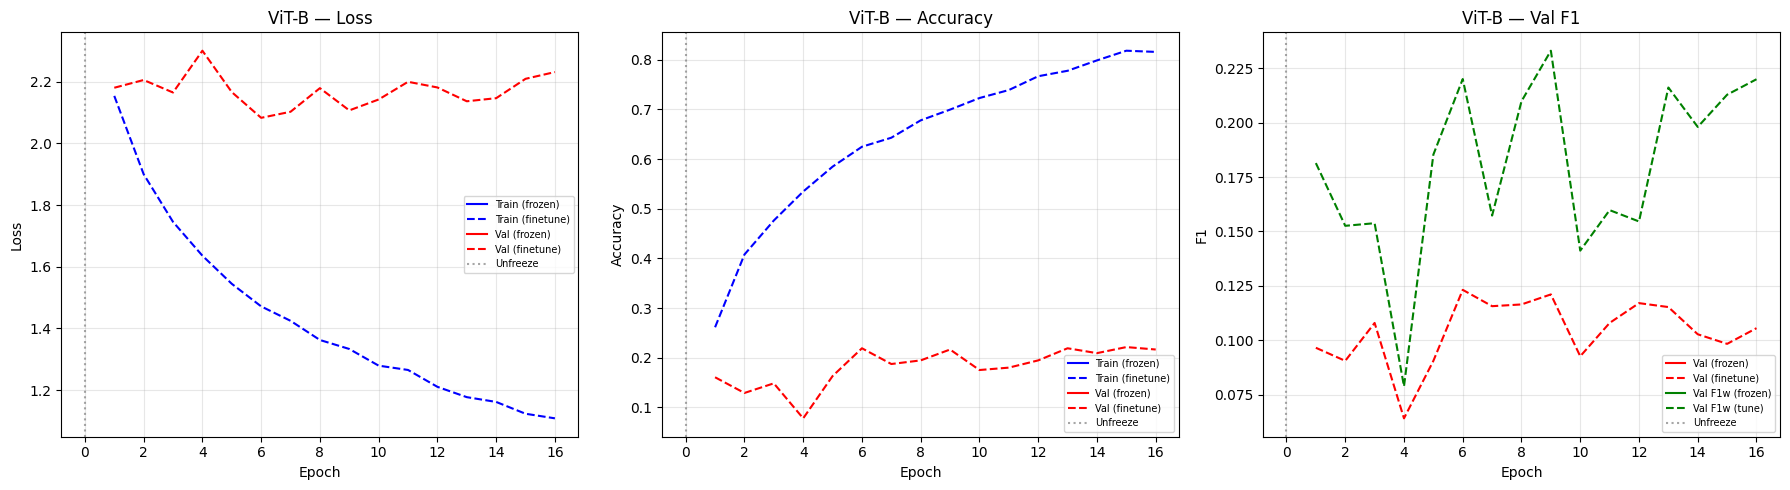

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
phase1_mask = hist_df["phase"] == "frozen"
phase2_mask = hist_df["phase"] == "finetune"

for ax_i, (col_tr, col_v, title, ylabel) in enumerate([
    ("train_loss", "val_loss", "Loss", "Loss"),
    ("train_acc", "val_acc", "Accuracy", "Accuracy"),
    (None, "val_f1_macro", "Val F1", "F1"),
]):
    ax = axes[ax_i]
    if col_tr:
        ax.plot(hist_df["epoch"][phase1_mask], hist_df[col_tr][phase1_mask], "b-", label="Train (frozen)")
        ax.plot(hist_df["epoch"][phase2_mask], hist_df[col_tr][phase2_mask], "b--", label="Train (finetune)")
    ax.plot(hist_df["epoch"][phase1_mask], hist_df[col_v][phase1_mask], "r-", label="Val (frozen)")
    ax.plot(hist_df["epoch"][phase2_mask], hist_df[col_v][phase2_mask], "r--", label="Val (finetune)")
    if col_v == "val_f1_macro":
        ax.plot(hist_df["epoch"][phase1_mask], hist_df["val_f1_weighted"][phase1_mask], "g-", label="Val F1w (frozen)")
        ax.plot(hist_df["epoch"][phase2_mask], hist_df["val_f1_weighted"][phase2_mask], "g--", label="Val F1w (tune)")
    ax.axvline(x=config["phase1_epochs"], color="gray", ls=":", alpha=0.7, label="Unfreeze")
    ax.set_title(f"ViT-B — {title}"); ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(log_dir / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Test Evaluation

In [9]:
print(f"\n{'='*60}")
print(f"TEST EVALUATION — best model from epoch {best_epoch}")
print(f"{'='*60}")
ckpt = torch.load(run_dir / "best_model.pt", weights_only=False, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
test_m = evaluate(model, test_loader, criterion, device, desc="  test")
print(f"\n  Test Accuracy:      {test_m['accuracy']:.4f}")
print(f"  Test F1 (macro):    {test_m['f1_macro']:.4f}")
print(f"  Test F1 (weighted): {test_m['f1_weighted']:.4f}")


TEST EVALUATION — best model from epoch 6


  test:   0%|          | 0/76 [00:00<?, ?it/s]


  Test Accuracy:      0.1728
  Test F1 (macro):    0.0965
  Test F1 (weighted): 0.1772


## 9. Per-class Report & F1 Bar Chart


Classification Report:
                   precision    recall  f1-score   support

                        0.00      0.00      0.00         1
        Challenge       0.26      0.10      0.14        50
             Dive       0.00      0.00      0.00         5
        Dont know       0.00      0.00      0.00         0
         Elbowing       0.13      0.33      0.18        21
         High leg       0.08      0.11      0.10         9
          Holding       0.04      0.03      0.03        33
          Pushing       0.04      0.14      0.06         7
Standing tackling       0.40      0.17      0.23       127
         Tackling       0.15      0.33      0.21        48

         accuracy                           0.17       301
        macro avg       0.11      0.12      0.10       301
     weighted avg       0.25      0.17      0.18       301



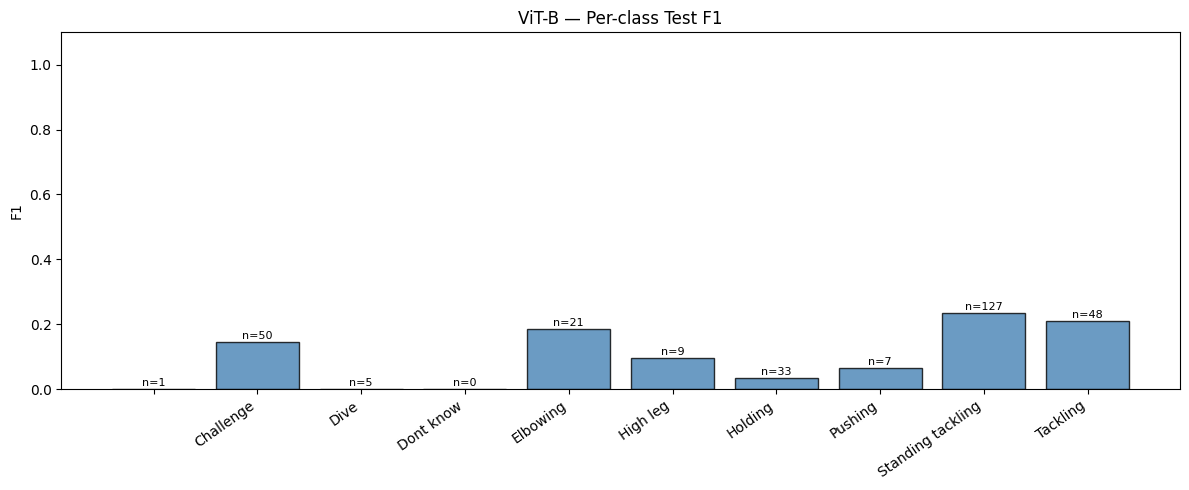

In [10]:
class_names = [idx_to_class.get(i, f"Class {i}") for i in range(n_classes)]
report_str = classification_report(test_m["labels"], test_m["preds"],
                                    target_names=class_names, zero_division=0)
print(f"\nClassification Report:\n{report_str}")
with open(run_dir / "test_report.txt", "w") as f:
    f.write(report_str)

report_dict = classification_report(test_m["labels"], test_m["preds"],
                                     target_names=class_names, zero_division=0, output_dict=True)
per_class = {k: v for k, v in report_dict.items() if k in class_names}
if per_class:
    fig, ax = plt.subplots(figsize=(12, 5))
    names = list(per_class.keys())
    f1s = [per_class[n]["f1-score"] for n in names]
    supports = [per_class[n]["support"] for n in names]
    bars = ax.bar(names, f1s, color="steelblue", edgecolor="black", alpha=0.8)
    for bar, s in zip(bars, supports):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"n={int(s)}", ha="center", fontsize=8)
    ax.set_title("ViT-B — Per-class Test F1"); ax.set_ylabel("F1"); ax.set_ylim(0, 1.1)
    plt.xticks(rotation=35, ha="right"); plt.tight_layout()
    plt.savefig(log_dir / "per_class_f1.png", dpi=150, bbox_inches="tight")
    plt.show()

## 10. Confusion Matrix

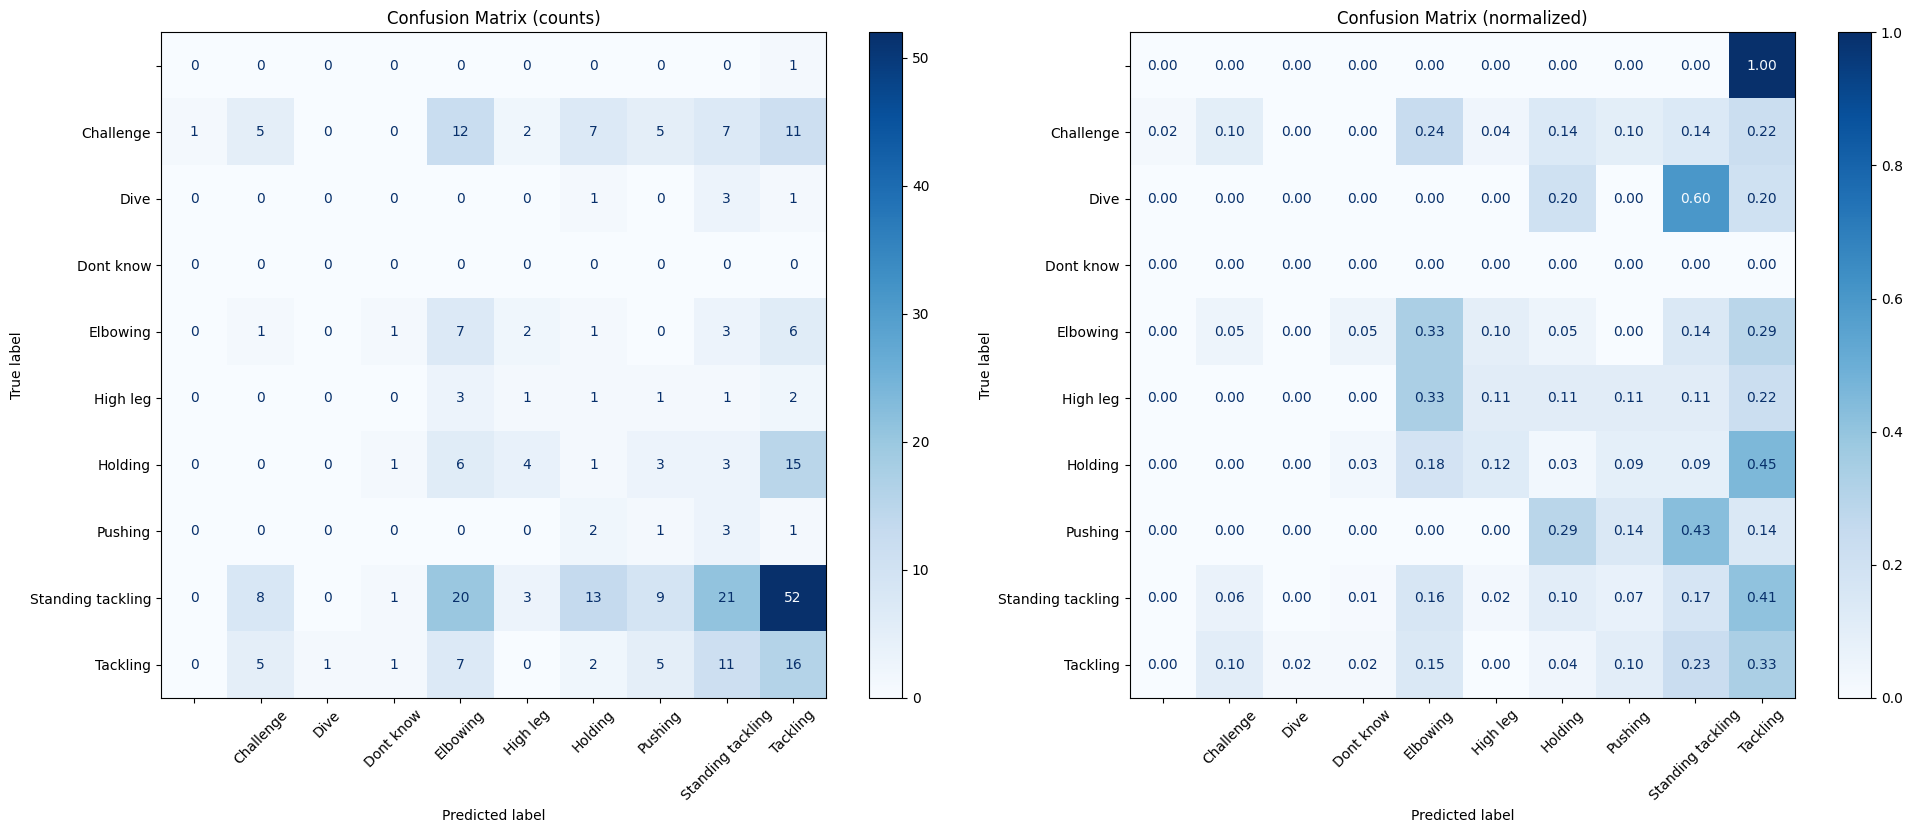

In [11]:
cm = confusion_matrix(test_m["labels"], test_m["preds"], labels=list(range(n_classes)))
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
disp1 = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp1.plot(ax=axes[0], cmap="Blues", values_format="d", xticks_rotation=45)
axes[0].set_title("Confusion Matrix (counts)")
cm_n = cm.astype(float); rs = cm_n.sum(axis=1, keepdims=True); rs[rs==0]=1; cm_n = cm_n/rs
disp2 = ConfusionMatrixDisplay(cm_n, display_labels=class_names)
disp2.plot(ax=axes[1], cmap="Blues", values_format=".2f", xticks_rotation=45)
axes[1].set_title("Confusion Matrix (normalized)")
plt.tight_layout()
plt.savefig(log_dir / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Save Results

In [12]:
results = {
    "best_epoch": best_epoch, "best_val_f1_macro": best_val_f1,
    "test_accuracy": test_m["accuracy"],
    "test_f1_macro": test_m["f1_macro"],
    "test_f1_weighted": test_m["f1_weighted"],
    "total_epochs": global_epoch, "run_name": run_name,
}
with open(run_dir / "results.json", "w") as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))

{
  "best_epoch": 6,
  "best_val_f1_macro": 0.12318897564722686,
  "test_accuracy": 0.17275747508305647,
  "test_f1_macro": 0.09654663703696939,
  "test_f1_weighted": 0.17722132626427894,
  "total_epochs": 16,
  "run_name": "vitb_gradual_20260507_090950"
}
